In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/SHA256SUMS.txt
/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/utility_sepsis_diagram.svg
/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/physionet_challenge_2019_ccm_manuscript.pdf
/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/utility_nonsepsis_diagram.svg
/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/LICENSE.txt
/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/Dataset.csv
/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/training_setA/training/p017072.psv
/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/training_setA/training/p016153.psv
/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/training_setA/training/p000465.psv
/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/training_setA/training/p009891.psv
/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/training_setA/training/p008065.psv
/kaggle/input/datasets/sa

In [2]:
import kagglehub
path=kagglehub.dataset_download("salikhussaini49/prediction-of-sepsis")
print("Path to datset files:",path)

Path to datset files: /kaggle/input/datasets/salikhussaini49/prediction-of-sepsis


In [3]:
import os
for dirname,_,filenames in os.walk(path):
    for filename in filenames[:10]:
        print(os.path.join(dirname,filename))
        

/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/SHA256SUMS.txt
/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/utility_sepsis_diagram.svg
/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/physionet_challenge_2019_ccm_manuscript.pdf
/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/utility_nonsepsis_diagram.svg
/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/LICENSE.txt
/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/Dataset.csv
/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/training_setA/training/p017072.psv
/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/training_setA/training/p016153.psv
/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/training_setA/training/p000465.psv
/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/training_setA/training/p009891.psv
/kaggle/input/datasets/salikhussaini49/prediction-of-sepsis/training_setA/training/p008065.psv
/kaggle/input/datasets/sa

In [4]:
import pandas as pd

In [5]:
df=pd.read_csv(path + "/Dataset.csv")
print(df.shape)
df.head()

(1552210, 44)


,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072
3,3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0,17072
4,4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,...,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0,17072


In [6]:
print("Total unique patients:",df["Patient_ID"].unique())
print("Sepsis cases(rows):",df["SepsisLabel"].sum())
print("Sepsis %:",round(df["SepsisLabel"].mean()*100,2), "%")
## datset is highly imbalanced as non sepsi is 98% and sepsis 1.8%

Total unique patients: [ 17072  16153    465 ... 105149 112699 113911]
Sepsis cases(rows): 27916
Sepsis %: 1.8 %


In [7]:
print("Total unique patients:",len(df["Patient_ID"].unique()))

Total unique patients: 40336


In [8]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_pct.head(15))

Bilirubin_direct    99.807371
Fibrinogen          99.340167
TroponinI           99.047745
Bilirubin_total     98.509158
Alkalinephos        98.393194
AST                 98.377604
Lactate             97.329872
PTT                 97.055875
SaO2                96.549372
EtCO2               96.286843
Phosphate           95.986303
HCO3                95.810618
Chloride            95.460279
BaseExcess          94.579020
PaCO2               94.440121
dtype: float64


In [9]:
# Identify columns with >90% missing values
high_missing_cols = missing_pct[missing_pct > 90].index.tolist()

# Safety check - make sure we don't accidentally drop important columns
protect_cols = ['Age', 'Gender', 'SepsisLabel', 'Patient_ID', 'Hour', 'ICULOS']
high_missing_cols = [col for col in high_missing_cols if col not in protect_cols]

print("Dropping these columns:", high_missing_cols)

df_clean = df.drop(columns=high_missing_cols)
print("New shape:", df_clean.shape)

Dropping these columns: ['Bilirubin_direct', 'Fibrinogen', 'TroponinI', 'Bilirubin_total', 'Alkalinephos', 'AST', 'Lactate', 'PTT', 'SaO2', 'EtCO2', 'Phosphate', 'HCO3', 'Chloride', 'BaseExcess', 'PaCO2', 'Calcium', 'Platelets', 'Creatinine', 'Magnesium', 'WBC', 'BUN', 'pH', 'Hgb', 'FiO2', 'Hct', 'Potassium']
New shape: (1552210, 18)


In [10]:
# Clinically important labs to keep despite high missingness
important_labs = ['Lactate', 'Creatinine', 'WBC', 'Platelets', 'pH', 'HCO3']

# Start from df_clean and add back the important labs
df_clean2 = df_clean.copy()
for lab in important_labs:
    df_clean2[lab] = df[lab]
    # Create indicator: was this lab measured at this hour?
    df_clean2[lab + '_measured'] = df[lab].notna().astype(int)

print("New shape:", df_clean2.shape)
df_clean2[important_labs].describe()

New shape: (1552210, 30)


,Lactate,Creatinine,WBC,Platelets,pH,HCO3
count,41446.000000,94616.000000,99447.000000,92209.000000,107573.000000,65028.000000
mean,2.646666,1.510699,11.446405,196.013911,7.378934,24.075481
std,2.526214,1.805603,7.731013,103.635366,0.074568,4.376504
min,0.200000,0.100000,0.100000,1.000000,6.620000,0.000000
25%,1.260000,0.700000,7.600000,126.000000,7.340000,22.000000
50%,1.800000,0.940000,10.300000,181.000000,7.380000,24.000000
75%,3.000000,1.430000,13.800000,244.000000,7.430000,26.800000
max,31.000000,46.600000,440.000000,2322.000000,7.930000,55.000000


In [11]:
# Sort by patient and time to ensure correct forward-fill order
df_clean2 = df_clean2.sort_values(['Patient_ID', 'ICULOS'])

# Forward-fill within each patient (carries last known value forward)
cols_to_fill = df_clean2.columns.difference(['Patient_ID', 'SepsisLabel', 'Hour', 'Unnamed: 0'])
df_clean2[cols_to_fill] = df_clean2.groupby('Patient_ID')[cols_to_fill].transform(lambda x: x.ffill())

# Any remaining missing (start of stay, never measured) - fill with column median
df_clean2[cols_to_fill] = df_clean2[cols_to_fill].fillna(df_clean2[cols_to_fill].median())

print("Remaining missing values:", df_clean2.isnull().sum().sum())

Remaining missing values: 0


In [15]:
# Check how many hours (timesteps) each patient has
hours_per_patient = df_clean2.groupby('Patient_ID').size()
print(hours_per_patient.describe())

count    40336.000000
mean        38.482001
std         22.795923
min          8.000000
25%         24.000000
50%         38.000000
75%         47.000000
max        336.000000
dtype: float64


In [13]:
SEQUENCE_LENGTH = 48

# Get list of feature columns (excluding ID, label, and helper columns)
feature_cols = df_clean2.columns.difference(['Patient_ID', 'SepsisLabel', 'Hour', 'Unnamed: 0'])
print("Number of features per timestep:", len(feature_cols))
print(list(feature_cols))

Number of features per timestep: 26
['Age', 'Creatinine', 'Creatinine_measured', 'DBP', 'Gender', 'Glucose', 'HCO3', 'HCO3_measured', 'HR', 'HospAdmTime', 'ICULOS', 'Lactate', 'Lactate_measured', 'MAP', 'O2Sat', 'Platelets', 'Platelets_measured', 'Resp', 'SBP', 'Temp', 'Unit1', 'Unit2', 'WBC', 'WBC_measured', 'pH', 'pH_measured']


In [14]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

patient_ids = df_clean2['Patient_ID'].unique()
sequences = []
labels = []

for pid in patient_ids:
    patient_data = df_clean2[df_clean2['Patient_ID'] == pid].sort_values('ICULOS')
    seq = patient_data[feature_cols].values[:SEQUENCE_LENGTH]
    label = patient_data['SepsisLabel'].values[:SEQUENCE_LENGTH].max()  # 1 if sepsis ever occurred in window
    sequences.append(seq)
    labels.append(label)

X = pad_sequences(sequences, maxlen=SEQUENCE_LENGTH, dtype='float32', padding='post', truncating='post')
y = np.array(labels)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (40336, 48, 26)
y shape: (40336,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("Train sepsis %:", round(y_train.mean()*100, 2))
print("Test sepsis %:", round(y_test.mean()*100, 2))

Train shape: (32268, 48, 26) (32268,)
Test shape: (8068, 48, 26) (8068,)
Train sepsis %: 4.65
Test sepsis %: 4.65


In [20]:
from sklearn.preprocessing import StandardScaler

# Reshape to 2D for scaling (samples*timesteps, features), then reshape back
n_train, timesteps, n_features = X_train.shape
X_train_2d = X_train.reshape(-1, n_features)
X_test_2d = X_test.reshape(-1, n_features)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_2d).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test_2d).reshape(X_test.shape)

print("Train scaled shape:", X_train_scaled.shape)
print("Sample values before scaling:", X_train[0, 0, :5])
print("Sample values after scaling:", X_train_scaled[0, 0, :5])

Train scaled shape: (32268, 48, 26)
Sample values before scaling: [72.8  0.9  0.  62.   0. ]
Sample values after scaling: [ 0.89101624 -0.04332234 -0.21678054  0.5128741  -0.8284616 ]


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, input_shape=(SEQUENCE_LENGTH, n_features), return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

I0000 00:00:1790065770.092445      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790065770.095662      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        23,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,409 (99.25 KB)

 Trainable params: 25,409 (99.25 KB)

 Non-trainable params: 0 (0.00 B)

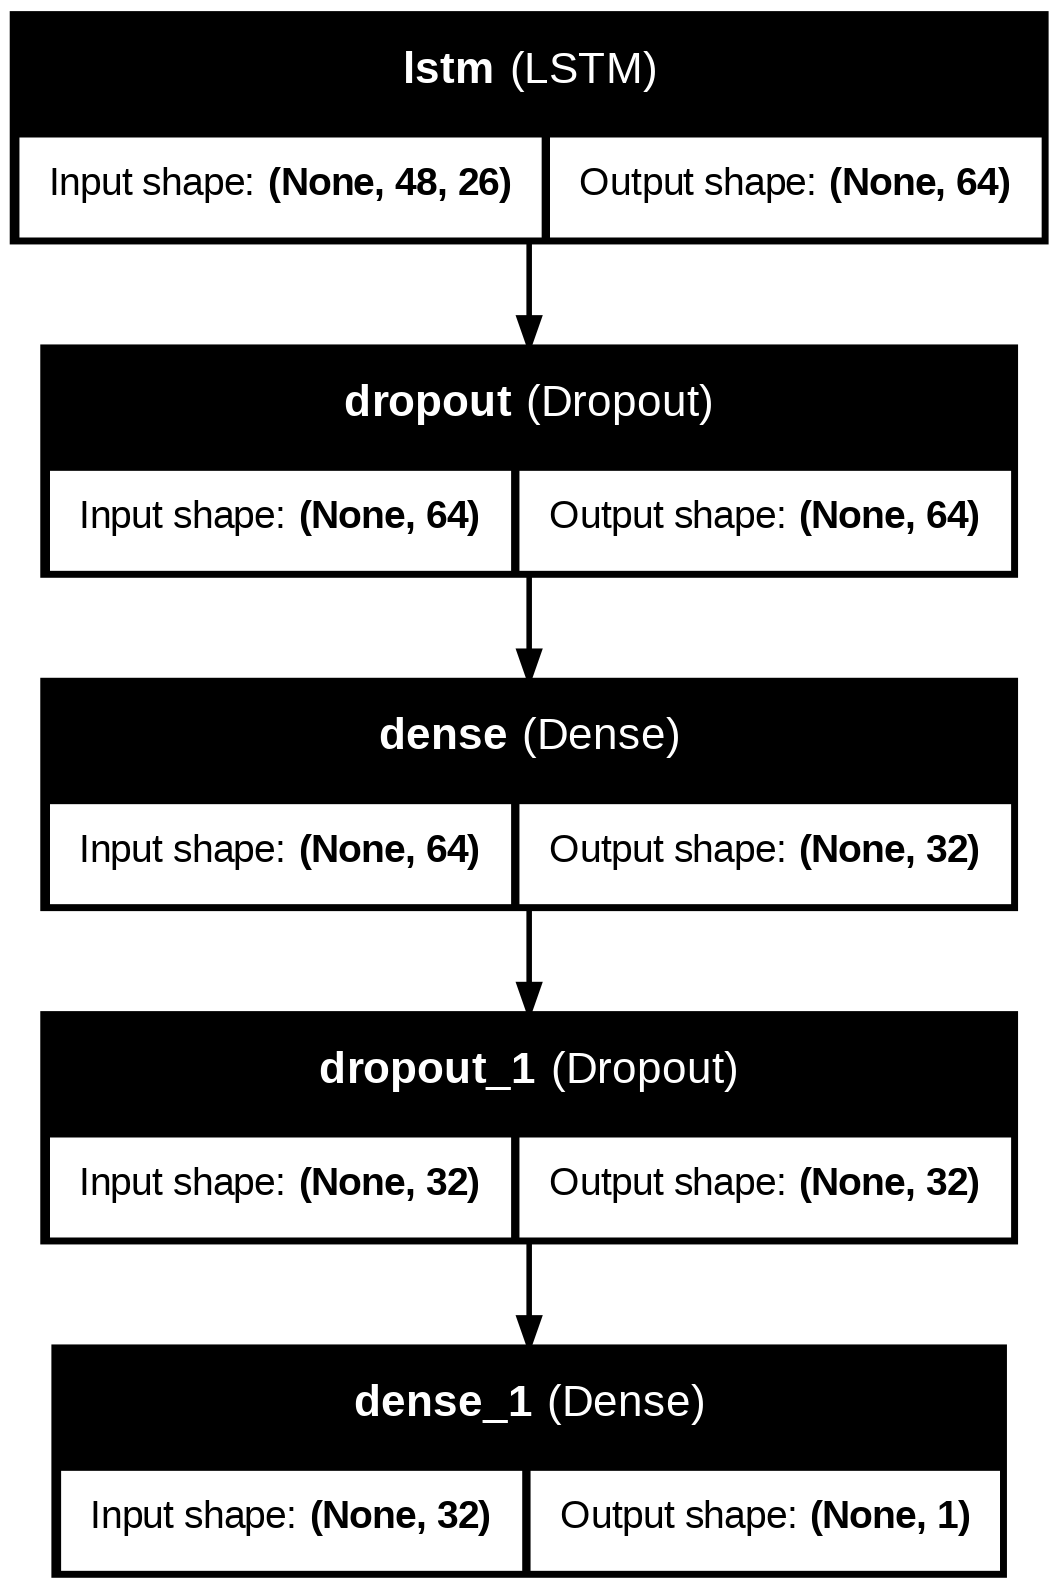

In [26]:
from tensorflow.keras.utils import plot_model

plot_model(model, to_file='lstm_model.png', show_shapes=True, show_layer_names=True, rankdir='TB')

from IPython.display import Image
Image('lstm_model.png')

In [23]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Class weights: {0: np.float64(0.524410063056621), 1: np.float64(10.74167776298269)}
Epoch 1/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7732 - loss: 0.5454 - val_accuracy: 0.7247 - val_loss: 0.5409
Epoch 2/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8550 - loss: 0.4475 - val_accuracy: 0.8057 - val_loss: 0.5036
Epoch 3/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8567 - loss: 0.4138 - val_accuracy: 0.9100 - val_loss: 0.2772
Epoch 4/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8615 - loss: 0.3938 - val_accuracy: 0.8791 - val_loss: 0.3698
Epoch 5/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8600 - loss: 0.3735 - val_accuracy: 0.8272 - val_loss: 0.3934
Epoch 6/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8618 - loss: 0.3604 - val_accuracy: 0.8844 - val_loss: 0.3169


## 

In [24]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_proba = model.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int)

print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.98      0.92      0.95      7693
           1       0.28      0.65      0.39       375

    accuracy                           0.91      8068
   macro avg       0.63      0.78      0.67      8068
weighted avg       0.95      0.91      0.92      8068

Confusion Matrix:
[[7069  624]
 [ 133  242]]


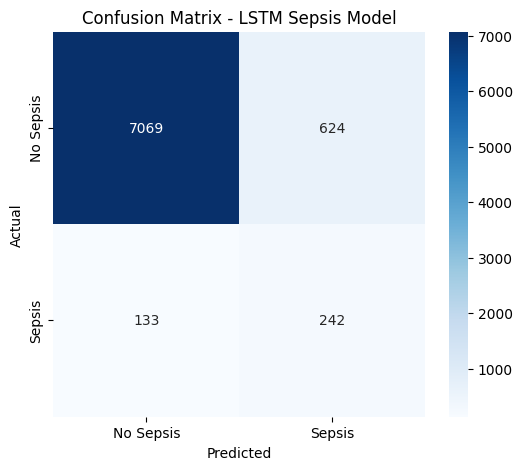

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Sepsis', 'Sepsis'], 
            yticklabels=['No Sepsis', 'Sepsis'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - LSTM Sepsis Model')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

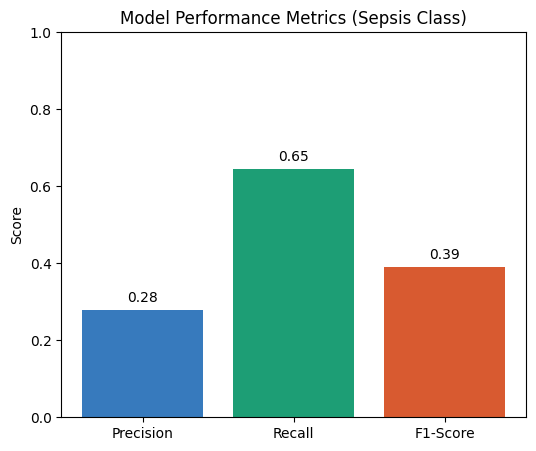

In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics = ['Precision', 'Recall', 'F1-Score']
values = [precision, recall, f1]

plt.figure(figsize=(6,5))
bars = plt.bar(metrics, values, color=['#377ABD', '#1D9E75', '#D85A30'])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Model Performance Metrics (Sepsis Class)')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2f}', ha='center')
plt.savefig('metrics_chart.png', dpi=150, bbox_inches='tight')
plt.show()

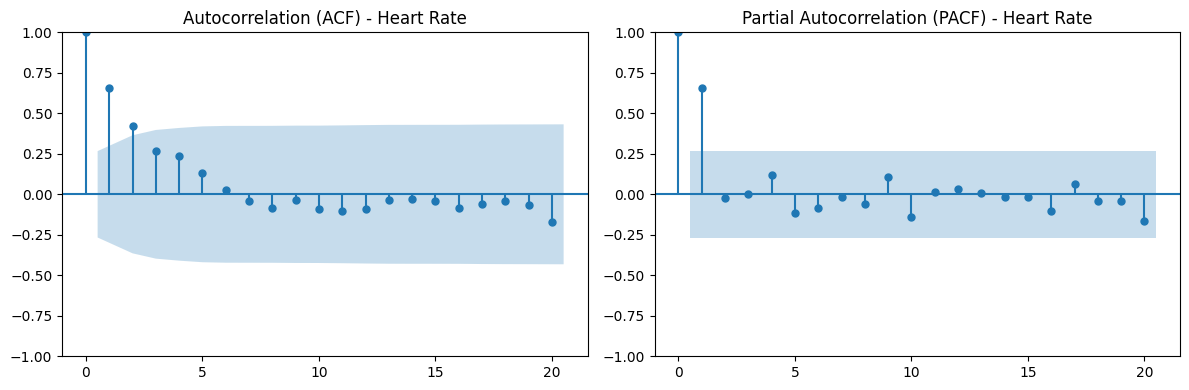

In [29]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Pick one patient's HR time-series as an example
sample_patient = df_clean2[df_clean2['Patient_ID'] == df_clean2['Patient_ID'].unique()[0]]
hr_series = sample_patient['HR'].values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(hr_series, ax=axes[0], lags=20)
axes[0].set_title('Autocorrelation (ACF) - Heart Rate')

plot_pacf(hr_series, ax=axes[1], lags=20)
axes[1].set_title('Partial Autocorrelation (PACF) - Heart Rate')

plt.tight_layout()
plt.savefig('acf_pacf_hr.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
from tensorflow.keras.layers import Input, LSTM, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.models import Model

inputs = Input(shape=(SEQUENCE_LENGTH, n_features))

lstm_out = LSTM(64, return_sequences=True)(inputs)

attention_out = MultiHeadAttention(num_heads=4, key_dim=16)(lstm_out, lstm_out)
attention_out = LayerNormalization()(attention_out + lstm_out)

pooled = GlobalAveragePooling1D()(attention_out)

x = Dense(32, activation='relu')(pooled)
x = Dropout(0.3)(x)
outputs = Dense(1, activation='sigmoid')(x)

hybrid_model = Model(inputs, outputs)
hybrid_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
hybrid_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 48, 26)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 48, 64)    │     23,296 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 48, 64)    │     16,640 │ lstm_1[0][0],     │
│ (MultiHeadAttentio… │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 48, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 48, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 42,177 (164.75 KB)

 Trainable params: 42,177 (164.75 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
early_stop_hybrid = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_hybrid = hybrid_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stop_hybrid]
)

Epoch 1/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8072 - loss: 0.5183 - val_accuracy: 0.8083 - val_loss: 0.5087
Epoch 2/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8479 - loss: 0.4602 - val_accuracy: 0.9137 - val_loss: 0.3540
Epoch 3/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8519 - loss: 0.4334 - val_accuracy: 0.7944 - val_loss: 0.5104
Epoch 4/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8537 - loss: 0.4126 - val_accuracy: 0.7629 - val_loss: 0.5534
Epoch 5/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8507 - loss: 0.3923 - val_accuracy: 0.8637 - val_loss: 0.3451
Epoch 6/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8473 - loss: 0.3728 - val_accuracy: 0.7963 - val_loss: 0.3811
Epoch 7/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8501 - loss: 0.3595 - val_accuracy: 0.8562 - val_loss: 0.3630
Epoch 8/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8563 - loss: 0.3420 - val_accu

In [32]:
from tensorflow.keras.layers import Input, LSTM, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

inputs = Input(shape=(SEQUENCE_LENGTH, n_features))

lstm_out = LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)(inputs)

attention_out = MultiHeadAttention(num_heads=4, key_dim=16, dropout=0.2)(lstm_out, lstm_out)
attention_out = LayerNormalization()(attention_out + lstm_out)

pooled = GlobalAveragePooling1D()(attention_out)

x = Dense(32, activation='relu', kernel_regularizer=l2(0.01))(pooled)
x = Dropout(0.4)(x)
outputs = Dense(1, activation='sigmoid')(x)

hybrid_model_v2 = Model(inputs, outputs)
hybrid_model_v2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
hybrid_model_v2.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 48, 26)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 48, 64)    │     23,296 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 48, 64)    │     16,640 │ lstm_2[0][0],     │
│ (MultiHeadAttentio… │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 48, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 48, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 32)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         33 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 42,177 (164.75 KB)

 Trainable params: 42,177 (164.75 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
early_stop_v2 = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_hybrid_v2 = hybrid_model_v2.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stop_v2]
)

Epoch 1/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 59s 133ms/step - accuracy: 0.7598 - loss: 0.8346 - val_accuracy: 0.8709 - val_loss: 0.5605
Epoch 2/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 53s 131ms/step - accuracy: 0.8309 - loss: 0.6154 - val_accuracy: 0.8595 - val_loss: 0.5018
Epoch 3/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 54s 133ms/step - accuracy: 0.8599 - loss: 0.5341 - val_accuracy: 0.9340 - val_loss: 0.3858
Epoch 4/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 54s 134ms/step - accuracy: 0.8738 - loss: 0.4931 - val_accuracy: 0.8999 - val_loss: 0.4611
Epoch 5/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 54s 133ms/step - accuracy: 0.8701 - loss: 0.4701 - val_accuracy: 0.7361 - val_loss: 0.6122
Epoch 6/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 54s 133ms/step - accuracy: 0.8655 - loss: 0.4595 - val_accuracy: 0.8725 - val_loss: 0.4756


In [35]:
y_pred_proba_v2 = hybrid_model_v2.predict(X_test_scaled)
y_pred_v2 = (y_pred_proba_v2 > 0.5).astype(int)

print("=== Regularized Hybrid Model (v2) ===")
print(classification_report(y_test, y_pred_v2))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_v2))

253/253 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step
=== Regularized Hybrid Model (v2) ===
              precision    recall  f1-score   support

           0       0.98      0.95      0.97      7693
           1       0.39      0.60      0.47       375

    accuracy                           0.94      8068
   macro avg       0.68      0.78      0.72      8068
weighted avg       0.95      0.94      0.94      8068

Confusion Matrix:
[[7332  361]
 [ 149  226]]


In [36]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]

print(f"{'Threshold':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10}")
for t in thresholds:
    y_pred_t = (y_pred_proba_v2 > t).astype(int)
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    print(f"{t:<10} {p:<10.3f} {r:<10.3f} {f1:<10.3f}")

Threshold  Precision  Recall     F1-Score  
0.3        0.133      0.805      0.228     
0.35       0.197      0.725      0.310     
0.4        0.272      0.656      0.384     
0.45       0.332      0.611      0.430     
0.5        0.385      0.603      0.470     


=== Final Model (Threshold = 0.4) ===
              precision    recall  f1-score   support

           0       0.98      0.91      0.95      7693
           1       0.27      0.66      0.38       375

    accuracy                           0.90      8068
   macro avg       0.63      0.79      0.67      8068
weighted avg       0.95      0.90      0.92      8068

Confusion Matrix:
[[7034  659]
 [ 129  246]]


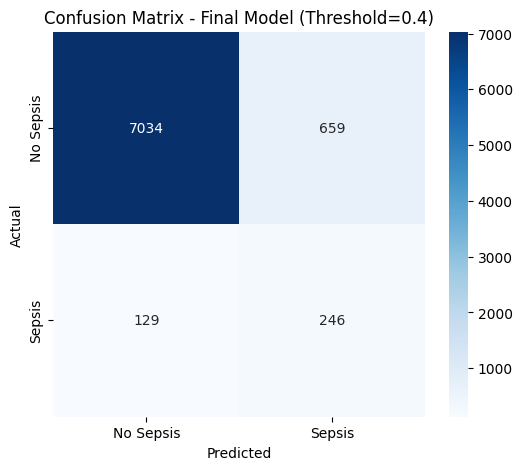

In [37]:
FINAL_THRESHOLD = 0.4

y_pred_final = (y_pred_proba_v2 > FINAL_THRESHOLD).astype(int)

print(f"=== Final Model (Threshold = {FINAL_THRESHOLD}) ===")
print(classification_report(y_test, y_pred_final))

cm_final = confusion_matrix(y_test, y_pred_final)
print("Confusion Matrix:")
print(cm_final)

plt.figure(figsize=(6,5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Sepsis', 'Sepsis'],
            yticklabels=['No Sepsis', 'Sepsis'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - Final Model (Threshold={FINAL_THRESHOLD})')
plt.savefig('confusion_matrix_final.png', dpi=150, bbox_inches='tight')
plt.show()
